In [17]:
import pandas as pd

file_path = "PrimeRx Datasets.xlsx"

alerts = pd.read_excel(file_path, sheet_name="Alerts")
top10_alerts = (
    alerts.groupby('HCP_ID')
          .size()
          .reset_index(name='Total_Alerts')
          .sort_values('Total_Alerts', ascending=False)
          .head(10)
          .reset_index(drop=True)
)

# ranking
top10_alerts.index += 1
top10_alerts.index.name = 'Rank'

print(top10_alerts)

      HCP_ID  Total_Alerts
Rank                      
1     HCP041           200
2     HCP011           198
3     HCP019           190
4     HCP020           188
5     HCP032           188
6     HCP021           185
7     HCP014           178
8     HCP036           176
9     HCP022           175
10    HCP007           173


In [18]:
sales = pd.read_excel(file_path, sheet_name="Sales")

# Only alerts data doctors
doctors_with_alerts = alerts['HCP_ID'].unique()

# top 10 doctors by total prescriptions written
top10_rx = (
    sales[sales['HCP_ID'].isin(doctors_with_alerts)]
    .groupby('HCP_ID')['Prescription_Volume']
    .sum()
    .reset_index()
    .sort_values('Prescription_Volume', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top10_rx.index += 1
top10_rx.index.name = 'Rank'

print(top10_rx)

      HCP_ID  Prescription_Volume
Rank                             
1     HCP185                 2900
2     HCP062                 2380
3     HCP019                 2277
4     HCP163                 2233
5     HCP126                 2196
6     HCP211                 2196
7     HCP154                 2187
8     HCP215                 2155
9     HCP088                 2084
10    HCP004                 2081


In [19]:
import pandas as pd
from datetime import timedelta

file_path = "PrimeRx Datasets.xlsx"

alerts = pd.read_excel(file_path, sheet_name="Alerts")
sales  = pd.read_excel(file_path, sheet_name="Sales")

# for dates datatype
alerts['Alert_Date']        = pd.to_datetime(alerts['Alert_Date'])
sales['Prescription_Date']  = pd.to_datetime(sales['Prescription_Date'])

# taking only positive lab results
positive_alerts = alerts[alerts['Lab_Result'] == 'Positive']

# 1st alert
first_positive = (
    positive_alerts.groupby('HCP_ID')['Alert_Date']
    .min()
    .reset_index()
)
first_positive.columns = ['HCP_ID', 'First_Positive_Date']

# Count prescriptions under 30 days of that first alert
result = []

for i in range(len(first_positive)):
    hcp        = first_positive.loc[i, 'HCP_ID']
    start_date = first_positive.loc[i, 'First_Positive_Date']
    end_date   = start_date + timedelta(days=30)

    rx_in_window = sales[
        (sales['HCP_ID'] == hcp) &
        (sales['Prescription_Date'] >= start_date) &
        (sales['Prescription_Date'] <= end_date)
    ].shape[0]

    result.append([hcp, rx_in_window])

followup = pd.DataFrame(result, columns=['HCP_ID', 'Rx_Count_30Days'])

# 0 prescription doctors
no_action_doctors = followup[followup['Rx_Count_30Days'] == 0]

# ranking based on alerts made (+ve)
alert_counts = positive_alerts.groupby('HCP_ID').size().reset_index(name='Positive_Alerts')

top10_no_action = (
    pd.merge(no_action_doctors, alert_counts, on='HCP_ID', how='left')
    .sort_values('Positive_Alerts', ascending=False)
    .head(10)
    .reset_index(drop=True)
)

top10_no_action.index += 1
top10_no_action.index.name = 'Rank'

print(top10_no_action)

      HCP_ID  Rx_Count_30Days  Positive_Alerts
Rank                                          
1     HCP041                0              127
2     HCP011                0              123
3     HCP021                0              116
4     HCP042                0              101
5     HCP023                0               99
6     HCP007                0               96
7     HCP026                0               78
8     HCP009                0               67
9     HCP001                0               63
10    HCP002                0               59


In [20]:
# Funnel: Stage 1: at least 1 positive alert doctos
positive_alerts = alerts[alerts['Lab_Result'] == 'Positive']
alert_counts    = positive_alerts.groupby('HCP_ID').size().reset_index(name='Positive_Alerts')

stage1_doctors = alert_counts[alert_counts['Positive_Alerts'] >= 1]
stage1_count   = stage1_doctors['HCP_ID'].nunique()

# Stage 2: 2 or more positive alerts
stage2_doctors = alert_counts[alert_counts['Positive_Alerts'] >= 2]
stage2_count   = stage2_doctors['HCP_ID'].nunique()

# Stage 3: wrote zero Rx in 30 days after first alert
from datetime import timedelta

first_positive = (
    positive_alerts.groupby('HCP_ID')['Alert_Date']
    .min().reset_index()
)
first_positive.columns = ['HCP_ID', 'First_Positive_Date']

rx_result = []

for i in range(len(first_positive)):
    hcp   = first_positive.loc[i, 'HCP_ID']
    start = first_positive.loc[i, 'First_Positive_Date']
    end   = start + timedelta(days=30)

    rx_count = sales[
        (sales['HCP_ID'] == hcp) &
        (sales['Prescription_Date'] >= start) &
        (sales['Prescription_Date'] <= end)
    ].shape[0]

    rx_result.append([hcp, rx_count])

rx_df    = pd.DataFrame(rx_result, columns=['HCP_ID', 'Rx_30Days'])
funnel   = pd.merge(alert_counts, rx_df, on='HCP_ID', how='left')

stage3_doctors = funnel[
    (funnel['Positive_Alerts'] >= 2) &
    (funnel['Rx_30Days'] == 0)
]
stage3_count = stage3_doctors['HCP_ID'].nunique()

print("Stage 1 (≥1 Positive Alert):", stage1_count)
print("Stage 2 (≥2 Positive Alerts):", stage2_count)
print("Stage 3 (≥2 Alerts + No Rx in 30 days):", stage3_count)

Stage 1 (≥1 Positive Alert): 214
Stage 2 (≥2 Positive Alerts): 198
Stage 3 (≥2 Alerts + No Rx in 30 days): 68


In [21]:
import pandas as pd

file_path = "PrimeRx Datasets.xlsx"
alerts = pd.read_excel(file_path, sheet_name="Alerts")
sales  = pd.read_excel(file_path, sheet_name="Sales")

# top 10 doctors by total alert count
top10_by_alerts = (
    alerts.groupby('HCP_ID').size()
    .reset_index(name='Total_Alerts')
    .sort_values('Total_Alerts', ascending=False)
    .head(10)
)

# sale data for only those 10 doctors
sales_top10 = sales[sales['HCP_ID'].isin(top10_by_alerts['HCP_ID'])]

# all drug combined, total prescription
total_rx = (
    sales_top10.groupby('HCP_ID')['Prescription_Volume']
    .sum().reset_index()
)
total_rx.columns = ['HCP_ID', 'Total_Prescription_Volume']

# drg001 prescriptions only
our_drug_rx = (
    sales_top10[sales_top10['Drug_ID'] == 'DRG001']
    .groupby('HCP_ID')['Prescription_Volume']
    .sum().reset_index()
)
our_drug_rx.columns = ['HCP_ID', 'Our_Drug_Volume']

# overall table
market_share = pd.merge(top10_by_alerts[['HCP_ID']], total_rx,    on='HCP_ID', how='left')
market_share = pd.merge(market_share,                our_drug_rx,  on='HCP_ID', how='left')


market_share['Total_Prescription_Volume'] = market_share['Total_Prescription_Volume'].fillna(0)
market_share['Our_Drug_Volume']           = market_share['Our_Drug_Volume'].fillna(0)

# competetior volume and share hold by them
market_share['Competitor_Volume']    = market_share['Total_Prescription_Volume'] - market_share['Our_Drug_Volume']
market_share['Our_Drug_Share_%']     = (market_share['Our_Drug_Volume']    / market_share['Total_Prescription_Volume'] * 100).round(2)
market_share['Competitor_Share_%']   = (market_share['Competitor_Volume']  / market_share['Total_Prescription_Volume'] * 100).round(2)

market_share = market_share.fillna(0)

print(market_share[['HCP_ID', 'Total_Prescription_Volume', 'Our_Drug_Share_%', 'Competitor_Share_%']])

   HCP_ID  Total_Prescription_Volume  Our_Drug_Share_%  Competitor_Share_%
0  HCP041                        0.0              0.00                0.00
1  HCP011                        0.0              0.00                0.00
2  HCP019                     2277.0             59.11               40.89
3  HCP020                      570.0             25.44               74.56
4  HCP032                     2075.0             59.13               40.87
5  HCP021                        0.0              0.00                0.00
6  HCP014                      944.0             71.08               28.92
7  HCP036                     1895.0             64.75               35.25
8  HCP022                     1363.0             62.00               38.00
9  HCP007                        0.0              0.00                0.00


In [22]:
# exclude drg001 from top 10
competitor_sales = sales_top10[sales_top10['Drug_ID'] != 'DRG001']

# highly competetior based on volume
top_competitor = (
    competitor_sales.groupby(['Drug_Name', 'Drug_ID'])['Prescription_Volume']
    .sum().reset_index()
    .sort_values('Prescription_Volume', ascending=False)
)

print(top_competitor.head(1))

  Drug_Name Drug_ID  Prescription_Volume
2   Rivalex  DRG002                 1470


In [23]:
import pandas as pd

file_path = "PrimeRx Datasets.xlsx"
alerts      = pd.read_excel(file_path, sheet_name="Alerts")
sales       = pd.read_excel(file_path, sheet_name="Sales")
affiliation = pd.read_excel(file_path, sheet_name="Affiliation")

# doctor affiliation to hospital-accounts
alerts_with_account = pd.merge(alerts, affiliation, on='HCP_ID', how='left')

# total alerts per account
account_alert_counts = (
    alerts_with_account.groupby('Account_ID')
    .size().reset_index(name='Total_Alerts')
)

# top acc by alert volm
top10_accounts = account_alert_counts.sort_values('Total_Alerts', ascending=False).head(10)

# drg001 sales linked to accounts
our_drug_sales        = sales[sales['Drug_ID'] == 'DRG001']
our_drug_with_account = pd.merge(our_drug_sales, affiliation, on='HCP_ID', how='left')

# volume per account
account_rx = (
    our_drug_with_account.groupby('Account_ID')['Prescription_Volume']
    .sum().reset_index()
)
account_rx.columns = ['Account_ID', 'Our_Drug_Prescription_Count']

account_summary = pd.merge(top10_accounts, account_rx, on='Account_ID', how='left')
account_summary['Our_Drug_Prescription_Count'] = account_summary['Our_Drug_Prescription_Count'].fillna(0)

# conversion ratio = prescriptions written per alert received
account_summary['Conversion_Ratio'] = (
    account_summary['Our_Drug_Prescription_Count'] / account_summary['Total_Alerts']
)

# low to high conversion ratio (which is needed to be looked more)
account_summary = account_summary.sort_values('Conversion_Ratio', ascending=True).reset_index(drop=True)
account_summary.index += 1
account_summary.index.name = 'Rank'

print(account_summary)

     Account_ID  Total_Alerts  Our_Drug_Prescription_Count  Conversion_Ratio
Rank                                                                        
1        ACC001          3296                        12297          3.730886
2        ACC003          1195                         4947          4.139749
3        ACC002          2350                        12223          5.201277
4        ACC004           530                         5402         10.192453
5        ACC005           585                         9148         15.637607
6        ACC006           493                         9887         20.054767
7        ACC012            85                         1804         21.223529
8        ACC009           100                         2699         26.990000
9        ACC007           114                         7072         62.035088
10       ACC010            92                         9616        104.521739


In [24]:
import pandas as pd

file_path   = "PrimeRx Datasets.xlsx"
alerts      = pd.read_excel(file_path, sheet_name="Alerts")
sales       = pd.read_excel(file_path, sheet_name="Sales")
affiliation = pd.read_excel(file_path, sheet_name="Affiliation")

# total no. of affiliated doctors per account
affiliated_count = (
    affiliation.groupby('Account_ID')['HCP_ID']
    .nunique().reset_index()
)
affiliated_count.columns = ['Account_ID', 'Affiliated_Doctors']

# drg001 with account info
our_drug            = sales[sales['Drug_ID'] == 'DRG001']
our_drug_with_acct  = pd.merge(our_drug, affiliation, on='HCP_ID', how='left')

# unique doctors prescribed drg001
active_prescribers = (
    our_drug_with_acct.groupby('Account_ID')['HCP_ID']
    .nunique().reset_index()
)
active_prescribers.columns = ['Account_ID', 'Active_Doctors']

# total prescription volume per account
rx_volume = (
    our_drug_with_acct.groupby('Account_ID')['Prescription_Volume']
    .sum().reset_index()
)
rx_volume.columns = ['Account_ID', 'Our_Drug_Prescription_Volume']


efficiency = (
    affiliated_count
    .merge(active_prescribers, on='Account_ID', how='left')
    .merge(rx_volume,          on='Account_ID', how='left')
)

efficiency['Active_Doctors']              = efficiency['Active_Doctors'].fillna(0)
efficiency['Our_Drug_Prescription_Volume'] = efficiency['Our_Drug_Prescription_Volume'].fillna(0)

# volume per active prescriber(to find productivity of each active doctor
efficiency['Prescription_Volume_per_Active_Doctor'] = (
    efficiency['Our_Drug_Prescription_Volume'] / efficiency['Active_Doctors']
).fillna(0)

# starting with low efficienccy
top10_low_efficiency = (
    efficiency.sort_values('Prescription_Volume_per_Active_Doctor', ascending=True)
    .head(10)
    .reset_index(drop=True)
)
top10_low_efficiency.index += 1
top10_low_efficiency.index.name = 'Rank'

print(top10_low_efficiency)

     Account_ID  Affiliated_Doctors  Active_Doctors  \
Rank                                                  
1        ACC022                   2             0.0   
2        ACC017                   3             1.0   
3        ACC015                   8             7.0   
4        ACC012                  10             7.0   
5        ACC009                  11            10.0   
6        ACC003                  24            15.0   
7        ACC018                   4             3.0   
8        ACC004                  17            13.0   
9        ACC008                   7             6.0   
10       ACC014                   6             6.0   

      Our_Drug_Prescription_Volume  Prescription_Volume_per_Active_Doctor  
Rank                                                                       
1                              0.0                               0.000000  
2                             59.0                              59.000000  
3                           1347.0 

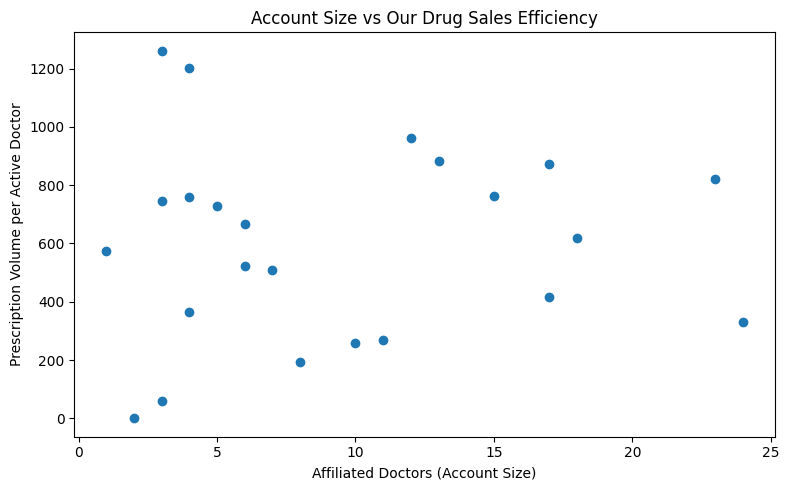

In [25]:
# scatterplot
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(
    efficiency['Affiliated_Doctors'],
    efficiency['Prescription_Volume_per_Active_Doctor']
)

plt.xlabel('Affiliated Doctors (Account Size)')
plt.ylabel('Prescription Volume per Active Doctor')
plt.title('Account Size vs Our Drug Sales Efficiency')

plt.tight_layout()
plt.show()

In [26]:
import pandas as pd
import numpy as np

file_path = "PrimeRx Datasets.xlsx"
alerts = pd.read_excel(file_path, sheet_name="Alerts")
sales  = pd.read_excel(file_path, sheet_name="Sales")

alerts['Alert_Date']       = pd.to_datetime(alerts['Alert_Date'])
sales['Prescription_Date'] = pd.to_datetime(sales['Prescription_Date'])

# +ve alert and 1st
positive_alerts = alerts[alerts['Lab_Result'] == 'Positive']
first_positive  = (
    positive_alerts.groupby('HCP_ID')['Alert_Date']
    .min().reset_index()
)
first_positive.columns = ['HCP_ID', 'First_Positive_Alert']

# for drg001
our_drug = sales[sales['Drug_ID'] == 'DRG001']

results = []

for _, row in first_positive.iterrows():
    hcp        = row['HCP_ID']
    alert_date = row['First_Positive_Alert']

    # 90 days before and 90 days after the first alert
    before_window = (alert_date - pd.Timedelta(days=90), alert_date - pd.Timedelta(days=1))
    after_window  = (alert_date, alert_date + pd.Timedelta(days=90))

    hcp_sales = our_drug[our_drug['HCP_ID'] == hcp]

    before_volume = hcp_sales[
        (hcp_sales['Prescription_Date'] >= before_window[0]) &
        (hcp_sales['Prescription_Date'] <= before_window[1])
    ]['Prescription_Volume'].sum()

    after_volume = hcp_sales[
        (hcp_sales['Prescription_Date'] >= after_window[0]) &
        (hcp_sales['Prescription_Date'] <= after_window[1])
    ]['Prescription_Volume'].sum()

    # %lift
    lift = ((after_volume - before_volume) / before_volume * 100) if before_volume > 0 else np.nan

    results.append([hcp, before_volume, after_volume, lift])

lift_df = pd.DataFrame(results, columns=['HCP_ID', 'Before_Volume', 'After_Volume', 'Lift_%'])

# a. tip 10 doctors by lift
partA = (
    lift_df.sort_values('Lift_%', ascending=False, na_position='last')
    .head(10)
    .reset_index(drop=True)
)
partA.index += 1
partA.index.name = 'Rank'
print("PART A — Top 10 Doctors by Prescription Lift")
print(partA)

# b. segment of each doctor
def classify_doctor(row):
    if row['Before_Volume'] == 0 and row['After_Volume'] > 0:
        return 'New Starters'       # started prescribing after the alert
    elif row['Before_Volume'] > 0 and row['Lift_%'] >= 20:
        return 'Growers'            # already prescribing, boost by 20%+
    else:
        return 'Non-responders'     # no significance chane

lift_df['Segment'] = lift_df.apply(classify_doctor, axis=1)

segment_summary = (
    lift_df.groupby('Segment')
    .agg(HCPs=('HCP_ID', 'count'), Avg_Lift=('Lift_%', 'mean'))
    .reset_index()
)

print("\nPART B — Doctor Segmentation")
print(segment_summary)

# strongest impact segment
strongest_segment = segment_summary.sort_values('Avg_Lift', ascending=False).head(1)
print("\nStrongest Commercial Impact Segment")
print(strongest_segment)

PART A — Top 10 Doctors by Prescription Lift
      HCP_ID  Before_Volume  After_Volume       Lift_%
Rank                                                  
1     HCP040              8           143  1687.500000
2     HCP050             10           107   970.000000
3     HCP006             32           249   678.125000
4     HCP108             31           238   667.741935
5     HCP016             50           279   458.000000
6     HCP159             42           232   452.380952
7     HCP157             72           387   437.500000
8     HCP211             42           223   430.952381
9     HCP209             64           335   423.437500
10    HCP125             49           214   336.734694

PART B — Doctor Segmentation
          Segment  HCPs    Avg_Lift
0         Growers    25  322.750836
1    New Starters    64         NaN
2  Non-responders   125  -68.158561

Strongest Commercial Impact Segment
   Segment  HCPs    Avg_Lift
0  Growers    25  322.750836
